# 🧠 Aula 04 - Parte 2: Regressão em PyTorch e Otimização Automática de Hiperparâmetros com Optuna

Nesta segunda parte da **Aula 04**, abordaremos o problema de **Regressão Tabular** utilizando o dataset de custos de seguro de saúde (*Insurance Dataset*).

Além da construção da rede neural para previsão de valores contínuos ($MSELoss$, $MAE$, $RMSE$, $R^2$), o foco principal desta aula é aprender a automatizar a escolha da arquitetura e dos hiperparâmetros utilizando a biblioteca **Optuna**.

---

### 🎯 Objetivos de Aprendizagem
1. **Prever Valores Contínuos com PyTorch**: Construir um pipeline de regressão para estimar os custos médicos individuais (`charges`).
2. **Entender Otimização Bayesiana (TPE)**: Compreender o funcionamento do algoritmo *Tree-structured Parzen Estimator* (TPE) do Optuna em substituição ao Grid Search e Random Search.
3. **Mecanismo de Pruning**: Utilizar a interrupção precoce de experimentos pouco promissores (*pruning*) para acelerar a busca.
4. **Construir um Estudo no Optuna**: Definir o espaço de busca contendo Taxa de Aprendizado, Arquitetura da Rede, Ativação, Normalização, Dropout e Batch Size.
5. **Visualizar a Importância dos Hiperparâmetros**: Interpretar gráficos de progresso de otimização, importância relativa dos hiperparâmetros e gráficos de coordenadas paralelas.
6. **Treinar e Avaliar o Modelo Definitivo**: Treinar o modelo final com a melhor combinação encontrada pelo Optuna e avaliar os resíduos no conjunto de Teste.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna

# Configuração de sementes para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Usando dispositivo: {device}")

🚀 Usando dispositivo: cpu


## 2. Dataset de Previsão de Custos Médicos (`insurance.csv`)

O dataset contém **1.338 registros** de segurados com os seguintes atributos:
- `age`: Idade do segurado principal.
- `sex`: Gênero (`female`, `male`).
- `bmi`: Índice de Massa Corporal (IMC).
- `children`: Número de dependentes cobertos.
- `smoker`: Indicador de fumante (`yes`, `no`).
- `region`: Região residencial nos EUA (`northeast`, `southeast`, `southwest`, `northwest`).
- **Target (`charges`)**: Custo médico anual cobrado pelo seguro em Dólares ($).

In [2]:
# 1. Carregar dataset
df_ins = pd.read_csv('insurance.csv')
print(f"📊 Dimensão do dataset: {df_ins.shape}")
print(df_ins.head(3))

# Separar atributos (X) e alvo (y)
X_raw = df_ins.drop(columns=['charges'])
y_raw = df_ins['charges'].values

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# 2. Divisão Estratificada/Aleatória: Treino (70%), Validação (15%), Teste (15%)
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42
)
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp, test_size=0.50, random_state=42
)

# 3. Preprocessador de Atributos com ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

# Ajuste EXCLUSIVO no conjunto de Treino
X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

# Escalonamento da Variável Alvo (y) para estabilizar o gradiente da rede
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

print(f"✅ Formato X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

📊 Dimensão do dataset: (1338, 7)
   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523
2   28    male  33.00         3     no  southeast   4449.4620
✅ Formato X_train: (936, 8) | X_val: (201, 8) | X_test: (201, 8)


## 3. Dataset, DataLoader e Arquitetura PyTorch para Regressão

Construiremos o `InsuranceDataset` e a classe modular `InsuranceMLP`. Como a tarefa é **Regressão**, a última camada linear possui saída contínua de tamanho 1 (`output_dim=1`) e não utiliza função de ativação na camada de saída.

In [3]:
class InsuranceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class InsuranceMLP(nn.Module):
    def __init__(
        self, 
        input_dim, 
        hidden_dims, 
        activation_cls, 
        norm_type, 
        dropout_rate
    ):
        super().__init__()
        layers = []
        in_dim = input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            
            if norm_type == 'batchnorm':
                layers.append(nn.BatchNorm1d(h_dim))
            elif norm_type == 'layernorm':
                layers.append(nn.LayerNorm(h_dim))
                
            layers.append(activation_cls())
            
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(dropout_rate))
                
            in_dim = h_dim
            
        # Camada final de saída contínua para regressão
        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

## 4. Otimização Bayesiana com Optuna & Conceitos Principais

Encontrar os melhores hiperparâmetros manualmente ou por busca em grade (*Grid Search*) é ineficiente e lento.

O **Optuna** utiliza **Otimização Bayesiana** com o algoritmo **TPE (Tree-structured Parzen Estimator)**:
1. **Modelagem Probabilística**: Conforme os experimentos são executados, o Optuna constrói um modelo estatístico das regiões do espaço de hiperparâmetros que produzem os menores erros.
2. **Navegação Inteligente**: Em vez de testar combinações aleatórias, os próximos testes (*trials*) concentram-se em áreas de alto desempenho.
3. **Mecanismo de Pruning**: Interrompe antecipadamente treinamentos que apresentam perdas de validação ruins nas primeiras épocas (`trial.should_prune()`).

### 🛠️ Espaço de Busca (*Search Space*):
- `lr`: Taxa de aprendizado entre $10^{-4}$ e $10^{-1}$ (escala logarítmica)
- `n_layers`: 1 a 3 camadas ocultas
- `n_units_l0`, `n_units_l1`, `n_units_l2`: 32 a 128 neurônios por camada
- `activation`: `ReLU`, `LeakyReLU` ou `ELU`
- `norm_type`: `None`, `BatchNorm` ou `LayerNorm`
- `dropout_rate`: 0.0 a 0.3
- `batch_size`: 16, 32 ou 64

In [4]:
def objective(trial):
    # 1. Sugestão de Hiperparâmetros
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_dims = [
        trial.suggest_int(f'n_units_l{i}', 32, 128, step=32) 
        for i in range(n_layers)
    ]
    
    activation_name = trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'elu'])
    act_map = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'elu': nn.ELU}
    act_cls = act_map[activation_name]
    
    norm_type = trial.suggest_categorical('norm_type', [None, 'batchnorm', 'layernorm'])
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.3)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    # 2. DataLoaders com o batch_size sugerido
    train_loader = DataLoader(InsuranceDataset(X_train, y_train_scaled), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(InsuranceDataset(X_val, y_val_scaled), batch_size=batch_size, shuffle=False)
    
    # 3. Instanciar Modelo, Função de Perda e Otimizador
    model = InsuranceMLP(X_train.shape[1], hidden_dims, act_cls, norm_type, dropout_rate).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val_loss = float('inf')
    
    # 4. Loop de Treinamento e Pruning
    for epoch in range(35):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            
        # Validação
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out = model(X_batch)
                val_loss += criterion(out, y_batch).item() * len(y_batch)
        val_loss /= len(val_loader.dataset)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            
        # Reportar e checar necessidade de Pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return best_val_loss

## 5. Execução do Estudo do Optuna

Criaremos um `study` com o objetivo de **minimizar** o erro quadrático médio no conjunto de validação, executando 25 experimentos automáticos.

In [5]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

set_seed(42)
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

print("⏳ Iniciando a busca de hiperparâmetros com Optuna (25 trials)...")
study.optimize(objective, n_trials=25)

print("\n🎉 Otimização concluída!")
print(f"🏆 Melhor Erro no Validação (MSE Escalonado): {study.best_value:.4f}")
print("📌 Melhores Hiperparâmetros Encontrados:")
for k, v in study.best_params.items():
    print(f"   • {k}: {v}")

⏳ Iniciando a busca de hiperparâmetros com Optuna (25 trials)...



🎉 Otimização concluída!
🏆 Melhor Erro no Validação (MSE Escalonado): 0.1254
📌 Melhores Hiperparâmetros Encontrados:
   • n_layers: 3
   • n_units_l0: 32
   • n_units_l1: 32
   • n_units_l2: 128
   • activation: elu
   • norm_type: batchnorm
   • dropout_rate: 0.25893102776267807
   • lr: 0.0074112997810832455
   • batch_size: 16


## 6. Visualização e Diagnóstico do Optuna

O Optuna fornece ferramentas visuais para analisar o comportamento do processo de busca:
1. **Histórico de Otimização**: Acompanha a redução do erro ao longo dos *trials*.
2. **Importância dos Hiperparâmetros**: Identifica quais hiperparâmetros exercem maior impacto no desempenho.
3. **Gráfico de Fatias (*Slice Plot*)**: Exibe a distribuição dos resultados em função de cada parâmetro.

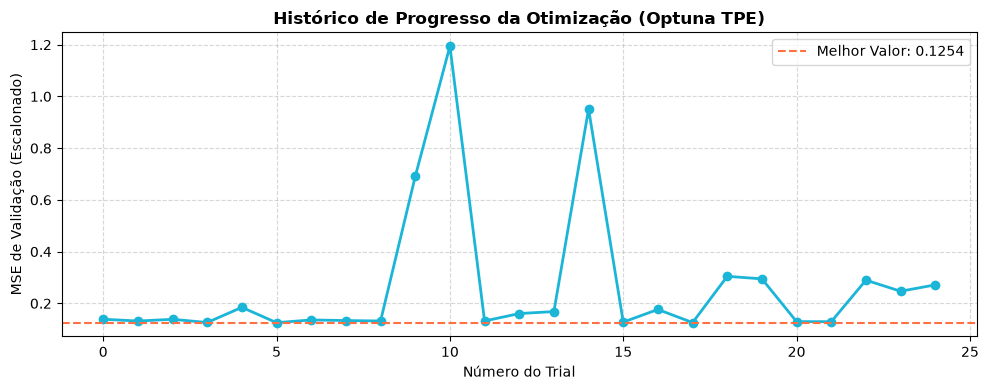

/tmp/ipykernel_14617/2169502936.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_values, y=param_names, palette='Blues_r')


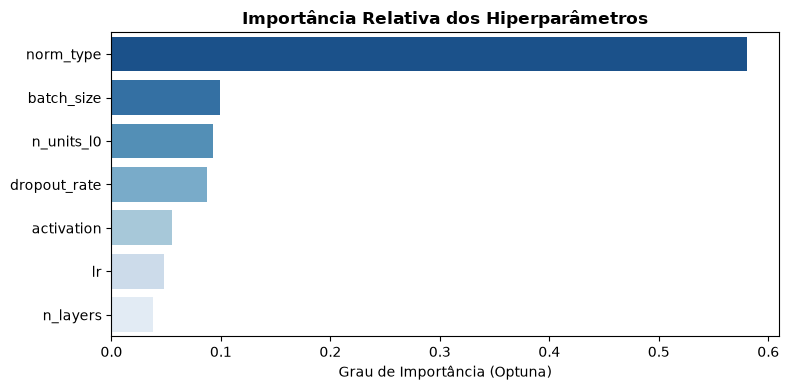

In [6]:
# Plot 1: Histórico de Otimização
df_trials = study.trials_dataframe()

plt.figure(figsize=(10, 4))
plt.plot(df_trials['number'], df_trials['value'], marker='o', color='#1BB5D8', linewidth=2)
plt.axhline(study.best_value, color='#FF7043', linestyle='--', label=f"Melhor Valor: {study.best_value:.4f}")
plt.title("Histórico de Progresso da Otimização (Optuna TPE)", fontsize=12, fontweight='bold')
plt.xlabel("Número do Trial")
plt.ylabel("MSE de Validação (Escalonado)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 2: Importância dos Hiperparâmetros
importances = optuna.importance.get_param_importances(study)
param_names = list(importances.keys())
importance_values = list(importances.values())

plt.figure(figsize=(8, 4))
sns.barplot(x=importance_values, y=param_names, palette='Blues_r')
plt.title("Importância Relativa dos Hiperparâmetros", fontsize=12, fontweight='bold')
plt.xlabel("Grau de Importância (Optuna)")
plt.tight_layout()
plt.show()

## 7. Treinamento do Modelo Definitivo & Avaliação no Teste

Com os melhores hiperparâmetros identificados pelo Optuna, treinaremos o modelo definitivo por 50 épocas e avaliaremos seu desempenho no conjunto de **Teste** desescalonando as previsões para a escala real em Dólares ($).

🏋️ Treinando modelo definitivo...



🎯 Métricas Finais no Conjunto de Teste (Escala Real em $):
   • MAE  (Erro Médio Absoluto): $3,153.43
   • RMSE (Raiz do Erro Quadrático Médio): $4,607.26
   • R² Score (Coeficiente de Determinação): 0.8600


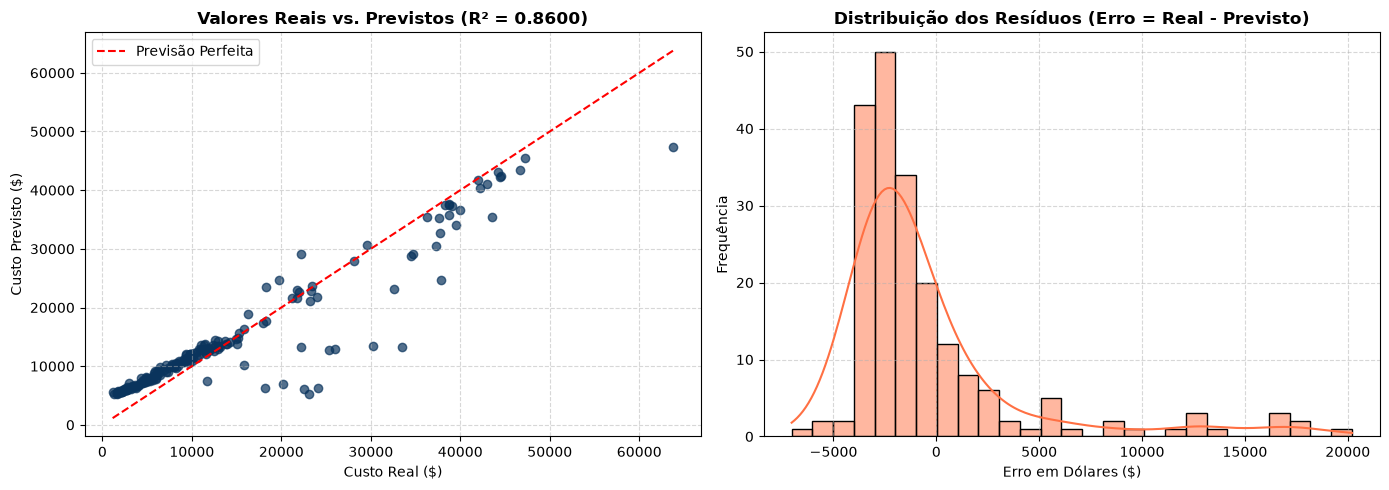

In [7]:
best_p = study.best_params

n_layers = best_p['n_layers']
hidden_dims = [best_p[f'n_units_l{i}'] for i in range(n_layers)]
act_cls = {'relu': nn.ReLU, 'leaky_relu': nn.LeakyReLU, 'elu': nn.ELU}[best_p['activation']]
norm_type = best_p['norm_type']
dropout_rate = best_p['dropout_rate']
lr = best_p['lr']
batch_size = best_p['batch_size']

set_seed(42)
final_model = InsuranceMLP(X_train.shape[1], hidden_dims, act_cls, norm_type, dropout_rate).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(final_model.parameters(), lr=lr)

train_loader_final = DataLoader(InsuranceDataset(X_train, y_train_scaled), batch_size=batch_size, shuffle=True)
test_loader_final = DataLoader(InsuranceDataset(X_test, y_test_scaled), batch_size=batch_size, shuffle=False)

# Treinamento Completo
print("🏋️ Treinando modelo definitivo...")
for epoch in range(1, 51):
    final_model.train()
    for X_batch, y_batch in train_loader_final:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = final_model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

# Avaliação no Teste
final_model.eval()
y_preds_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader_final:
        X_batch = X_batch.to(device)
        preds = final_model(X_batch).cpu().numpy()
        y_preds_scaled.extend(preds.flatten())

# Desescalonar Previsões para a moeda original ($)
y_preds_dollars = y_scaler.inverse_transform(np.array(y_preds_scaled).reshape(-1, 1)).flatten()

# Cálculo de Métricas Finais em Dólares
mae = mean_absolute_error(y_test, y_preds_dollars)
rmse = np.sqrt(mean_squared_error(y_test, y_preds_dollars))
r2 = r2_score(y_test, y_preds_dollars)

print("\n🎯 Métricas Finais no Conjunto de Teste (Escala Real em $):")
print(f"   • MAE  (Erro Médio Absoluto): ${mae:,.2f}")
print(f"   • RMSE (Raiz do Erro Quadrático Médio): ${rmse:,.2f}")
print(f"   • R² Score (Coeficiente de Determinação): {r2:.4f}")

# Gráfico de Valores Reais vs. Previstos e Resíduos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Previsto
axes[0].scatter(y_test, y_preds_dollars, alpha=0.7, color='#0A345D')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Previsão Perfeita')
axes[0].set_title(f"Valores Reais vs. Previstos (R² = {r2:.4f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Custo Real ($)")
axes[0].set_ylabel("Custo Previsto ($)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Histograma de Resíduos
residuals = y_test - y_preds_dollars
sns.histplot(residuals, kde=True, ax=axes[1], color='#FF7043')
axes[1].set_title("Distribuição dos Resíduos (Erro = Real - Previsto)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Erro em Dólares ($)")
axes[1].set_ylabel("Frequência")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Conclusão e Resumo Pedagógico

Nesta segunda parte da Aula 04, aprendemos:
- **MLP para Regressão Tabular**: Adaptação da camada final (`output_dim=1` sem ativação) e métricas contínuas ($MAE$, $RMSE$, $R^2$).
- **Busca por Hiperparâmetros com Optuna**: Utilização do amostrador TPE (*Tree-structured Parzen Estimator*) para navegar inteligentemente pelo espaço de hiperparâmetros.
- **Interrupção Precoce (Pruning)**: Como descartar experimentos de baixo desempenho antecipadamente para economizar recurso computacional.
- **Interpretação e Avaliação**: Importância de desescalonar previsões para avaliar erros na unidade original de negócio ($ Dólares) e analisar a distribuição dos resíduos.

---
Com isso, concluímos com sucesso a **Aula 04**!